# Assignment 1 — Part A: BER Analysis of BPSK, QPSK & 16-QAM over AWGN

**Course:** Wireless Communications Lab (WCL), IIT Delhi  
**Team 08:** Limnesh Augustine & Satheesh Papisetty  
**Date:** March 2026

---

## Objective
Simulate and compare the Bit Error Rate (BER) performance of three digital modulation schemes over an Additive White Gaussian Noise (AWGN) channel:

| Scheme  | Bits/Symbol | Spectral Efficiency | BER Formula |
|---------|-------------|---------------------|-------------|
| BPSK    | 1           | 1 b/s/Hz            | Q(√(2Eₓ/N₀)) |
| QPSK    | 2           | 2 b/s/Hz            | Q(√(2Eₓ/N₀)) |
| 16-QAM  | 4           | 4 b/s/Hz            | (3/4)·Q(√(4Eₓ/5N₀)) |

Monte Carlo simulation (N = 10,000 bits) is validated against closed-form Q-function expressions.

## 1. Imports & Utility Functions

All required libraries and core helper functions are defined here:
- **Q-function** via `scipy.special.erfc`
- **Modulation/Demodulation** for BPSK, QPSK, 16-QAM
- **AWGN noise generators** for real and complex channels
- **Monte Carlo BER simulators** for each scheme
- **Theoretical BER formulas** for each scheme

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# -----------------------------
# Utilities
# -----------------------------
# ----------------------------
# Helpers: Q-function
# ----------------------------
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))

# BPSK Functions
# Modulation
def bpsk_mod(bits):
    return 2*bits - 1  # 0->-1, 1->+1

# DeModulation
def bpsk_demod(x_real):
    return (x_real >= 0).astype(int)

# QPSK Functions
# Modulation
def qpsk_mod(bits):
    
    bits = bits.reshape(-1,2)

    I = 2*bits[:,0] - 1
    Q = 2*bits[:,1] - 1

    symbols = (I + 1j*Q)/np.sqrt(2)

    return symbols

# DeModulation
def qpsk_demod(symbols):

    bits = np.zeros((len(symbols),2),dtype=int)

    bits[:,0] = (symbols.real >= 0).astype(int)
    bits[:,1] = (symbols.imag >= 0).astype(int)

    return bits.reshape(-1)

# QAM Functions
# Modulation
def qam16_mod(bits):

    bits = bits.reshape(-1,4)

    b0 = bits[:,0]
    b1 = bits[:,1]
    b2 = bits[:,2]
    b3 = bits[:,3]

    #I = (2*b0 + b1)*2 - 3 
    #Q = (2*b2 + b3)*2 - 3

    # Gray mapping to match demodulator logic
    I = (2*b0 - 1) * (3 - 2*b1)
    Q = (2*b2 - 1) * (3 - 2*b3)

    symbols = (I + 1j*Q)/np.sqrt(10)

    return symbols

# DeModulation
def qam16_demod(symbols):

    symbols = symbols*np.sqrt(10)

    I = symbols.real
    Q = symbols.imag

    bits = np.zeros((len(symbols),4),dtype=int)

    bits[:,0] = (I > 0).astype(int)
    bits[:,1] = (np.abs(I) < 2).astype(int)

    bits[:,2] = (Q > 0).astype(int)
    bits[:,3] = (np.abs(Q) < 2).astype(int)

    return bits.reshape(-1)

# ----------------------------
# Additive White Gaussian Noise (AWGN) Functions
# ----------------------------
def awgn_sim_real(N_bits, EbN0_dB):
    # real AWGN for real-valued AWGN channel
    EbN0_linear = 10**(EbN0_dB/10)
    noise_std = np.sqrt(1/(2*EbN0_linear))
    return noise_std * np.random.randn(N_bits)

#def awgn_complex(shape, EbN0_dB):
#    # complex AWGN for complex-valued AWGN channel
#    EbN0_linear = 10**(EbN0_dB/10)
#    sigma = np.sqrt(1/(2*EbN0_linear))
#    return sigma * (np.random.randn(*shape) + 1j*np.random.randn(*shape))

def awgn_complex(shape, EbN0_dB, k):
    # complex AWGN for complex-valued AWGN channel
    # k is the number of bits per symbol - 2 for QPSK and 4 for QAM16
    EbN0_linear = 10**(EbN0_dB/10)
    EsN0_linear = k * EbN0_linear # Scale Eb/N0 to Es/N0
    sigma = np.sqrt(1/(2*EsN0_linear))
    return sigma * (np.random.randn(*shape) + 1j*np.random.randn(*shape))

# ----------------------------
# AWGN Channel Simulation - BPSK
# ----------------------------
def ber_awgn_sim_bpsk(N_bits, EbN0_dB_vec):
    ber = []
    bits = np.random.randint(0, 2, N_bits)
    s = bpsk_mod(bits)

    for EbN0 in EbN0_dB_vec:
        n = awgn_sim_real(N_bits, EbN0)
        r = s + n
        bits_hat = bpsk_demod(r)  # r is real
        ber.append(np.mean(bits != bits_hat))

    return np.array(ber)

# ----------------------------
# AWGN Channel Simulation - QPSK
# ----------------------------
def ber_awgn_sim_qpsk(N_bits, EbN0_dB_vec):
    ber = []
    bits = np.random.randint(0, 2, N_bits)
    s = qpsk_mod(bits)

    for EbN0 in EbN0_dB_vec:
        n = awgn_complex(s.shape, EbN0, 2)
        r = s + n
        bits_hat = qpsk_demod(r)  # r is complex
        ber.append(np.mean(bits != bits_hat))

    return np.array(ber)

# ----------------------------
# AWGN Channel Simulation - QAM 16
# ----------------------------
def ber_awgn_sim_qam16(N_bits, EbN0_dB_vec):
    ber = []
    bits = np.random.randint(0, 2, N_bits)
    s = qam16_mod(bits)

    for EbN0 in EbN0_dB_vec:
        n = awgn_complex(s.shape, EbN0, 4)
        r = s + n
        bits_hat = qam16_demod(r)  # r is complex
        ber.append(np.mean(bits != bits_hat))

    return np.array(ber)

# ----------------------------
# Analytical BER Functions
# ----------------------------
def ber_awgn_theory_bpsk(EbN0_dB):
    EbN0_linear = 10**(EbN0_dB/10)
    return qfunc(np.sqrt(2*EbN0_linear))

def ber_awgn_theory_qpsk(EbN0_dB):
    EbN0_linear = 10**(EbN0_dB/10)
    return qfunc(np.sqrt(2*EbN0_linear))

def ber_awgn_theory_qam16(EbN0_dB):
    EbN0_linear = 10**(EbN0_dB/10)
    return (3/4) * qfunc(np.sqrt((4/5)*EbN0_linear))

## 2. BPSK — Single-Point BER & Constellation

Demonstrate BPSK modulation, AWGN channel, demodulation, and BER at a single operating point (Eₓ/N₀ = 10 dB).

**Expected result:** BER ≈ 10⁻⁴ at 10 dB.

BPSK BER at Eb/N0 = 10 dB:  0.000000


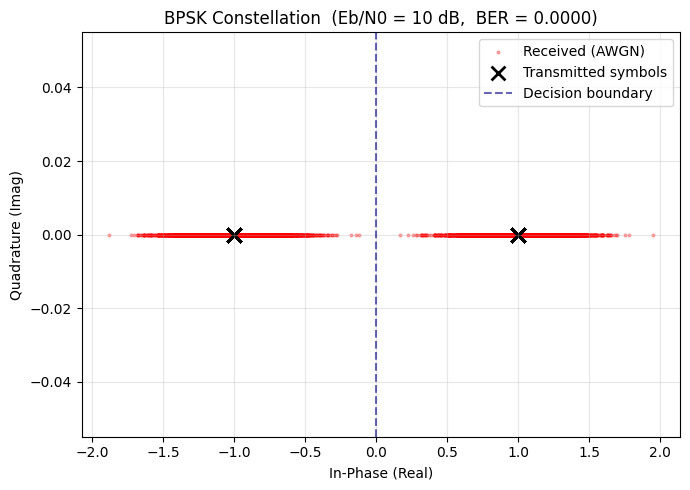

In [7]:
N_bits  = 10000   # Number of bits
EbN0_dB = 10      # Operating point (dB)

# Generate random bit stream
input_bits = np.random.randint(0, 2, N_bits)

# Modulate  →  Add AWGN  →  Demodulate
modulated_signal = bpsk_mod(input_bits)
received_signal  = modulated_signal + awgn_sim_real(N_bits, EbN0_dB)
demodulated_data = bpsk_demod(received_signal)

# BER
BER = np.mean(input_bits != demodulated_data)
print(f"BPSK BER at Eb/N0 = {EbN0_dB} dB:  {BER:.6f}")

# Constellation Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(received_signal.real, np.zeros_like(received_signal),
           marker='.', color='red', alpha=0.3, s=15, label='Received (AWGN)')
ax.scatter(modulated_signal.real, np.zeros_like(modulated_signal),
           marker='x', color='black', s=100, linewidths=2, label='Transmitted symbols')
ax.axvline(0, color='navy', linestyle='--', alpha=0.6, label='Decision boundary')
ax.set_title(f'BPSK Constellation  (Eb/N0 = {EbN0_dB} dB,  BER = {BER:.4f})')
ax.set_xlabel('In-Phase (Real)'); ax.set_ylabel('Quadrature (Imag)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. QPSK — Single-Point BER & Constellation

QPSK transmits 2 bits per symbol.  
**Expected:** BER identical to BPSK at same Eₓ/N₀.

QPSK BER at Eb/N0 = 10 dB:  0.000100


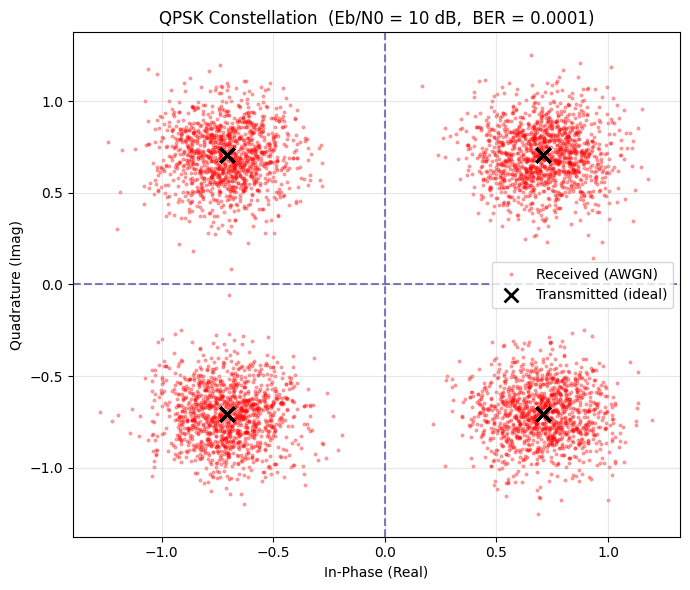

In [8]:
N_bits  = 10000
EbN0_dB = 10

input_bits       = np.random.randint(0, 2, N_bits)
modulated_signal = qpsk_mod(input_bits)
received_signal  = modulated_signal + awgn_complex(modulated_signal.shape, EbN0_dB, 2)
demodulated_data = qpsk_demod(received_signal)

BER = np.mean(input_bits != demodulated_data)
print(f"QPSK BER at Eb/N0 = {EbN0_dB} dB:  {BER:.6f}")

# Constellation Plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(received_signal.real, received_signal.imag,
           marker='.', color='red', alpha=0.3, s=15, label='Received (AWGN)')
ax.scatter(modulated_signal.real, modulated_signal.imag,
           marker='x', color='black', s=100, linewidths=2, label='Transmitted (ideal)')
ax.axhline(0, color='navy', linestyle='--', alpha=0.5)
ax.axvline(0, color='navy', linestyle='--', alpha=0.5)
ax.set_title(f'QPSK Constellation  (Eb/N0 = {EbN0_dB} dB,  BER = {BER:.4f})')
ax.set_xlabel('In-Phase (Real)'); ax.set_ylabel('Quadrature (Imag)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 16-QAM — Single-Point BER & Constellation

16-QAM transmits 4 bits per symbol.  
**Expected:** Higher BER than BPSK/QPSK at same Eₓ/N₀ due to denser constellation (~6.2 dB penalty).

16-QAM BER at Eb/N0 = 10 dB:  0.001500


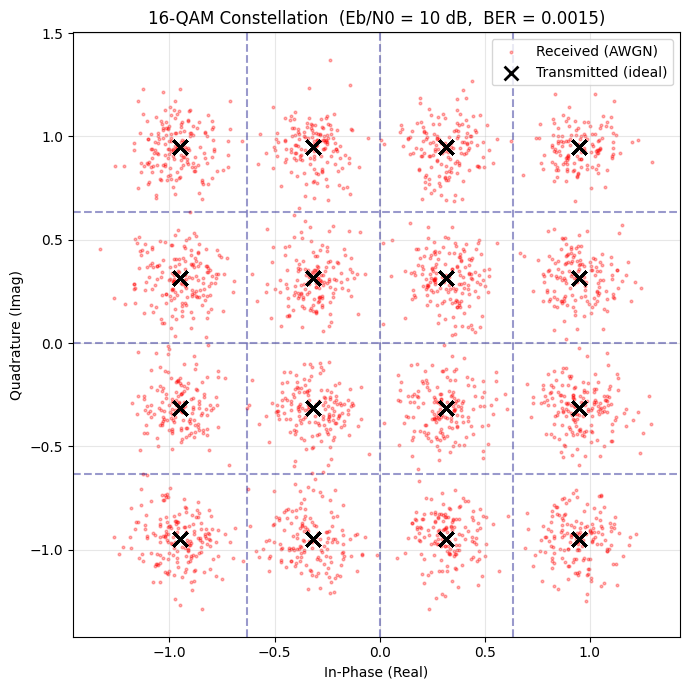

In [9]:
N_bits  = 10000
EbN0_dB = 10

input_bits       = np.random.randint(0, 2, N_bits)
modulated_signal = qam16_mod(input_bits)
received_signal  = modulated_signal + awgn_complex(modulated_signal.shape, EbN0_dB, 4)
demodulated_data = qam16_demod(received_signal)

BER = np.mean(input_bits != demodulated_data)
print(f"16-QAM BER at Eb/N0 = {EbN0_dB} dB:  {BER:.6f}")

# Constellation Plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(received_signal.real, received_signal.imag,
           marker='.', color='red', alpha=0.3, s=15, label='Received (AWGN)')
ax.scatter(modulated_signal.real, modulated_signal.imag,
           marker='x', color='black', s=100, linewidths=2, label='Transmitted (ideal)')
# Decision threshold lines
for th in [-2/np.sqrt(10), 0, 2/np.sqrt(10)]:
    ax.axhline(th, color='navy', linestyle='--', alpha=0.4)
    ax.axvline(th, color='navy', linestyle='--', alpha=0.4)
ax.set_title(f'16-QAM Constellation  (Eb/N0 = {EbN0_dB} dB,  BER = {BER:.4f})')
ax.set_xlabel('In-Phase (Real)'); ax.set_ylabel('Quadrature (Imag)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Full BER Simulation — Eb/N0 Sweep (0–20 dB)

Run Monte Carlo simulation over the full Eb/N0 range and compare all three schemes against theoretical BER curves.

**Key results to observe:**
- BPSK and QPSK curves overlap perfectly
- 16-QAM curve is shifted ~6.2 dB to the right at BER = 10⁻³

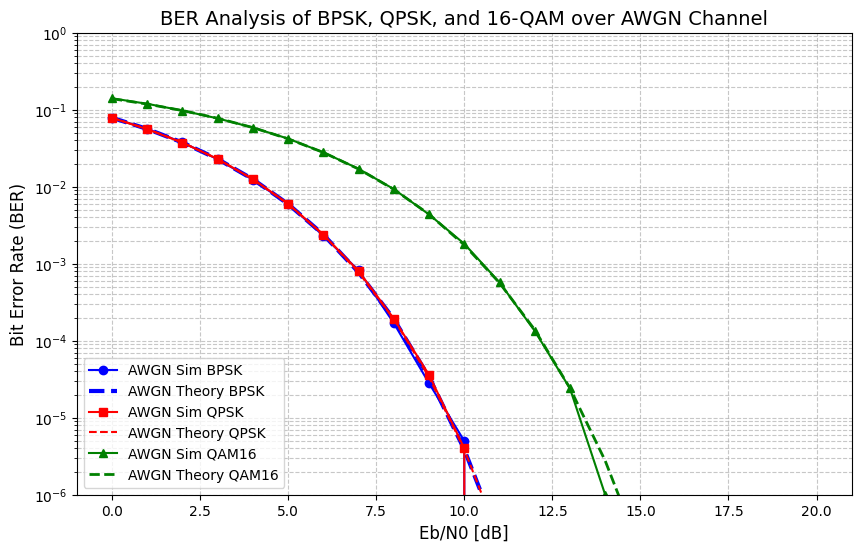

In [10]:
N_bits = 1000000 #Data length

#Extra check for 4 bit multiple for QAM16 and 2 bit multiple for QPSK
if N_bits % 4 != 0:
    N_bits += 4 - (N_bits % 4)

EbN0_dB = np.arange(0, 21, 1)   # 0 to 20 dB in steps of 2 dB

# ----------------------------
# Run simulations
# ----------------------------
ber_awgn_bpsk = ber_awgn_sim_bpsk(N_bits, EbN0_dB)
ber_awgn_qpsk = ber_awgn_sim_qpsk(N_bits, EbN0_dB)
ber_awgn_qam16 = ber_awgn_sim_qam16(N_bits, EbN0_dB)

# ----------------------------
# BER Theoretical
# ----------------------------
ber_awgn_bpsk_theory = ber_awgn_theory_bpsk(EbN0_dB)
ber_awgn_qpsk_theory = ber_awgn_theory_qpsk(EbN0_dB)
ber_awgn_qam16_theory = ber_awgn_theory_qam16(EbN0_dB)


# ----------------------------
# Plot results
# ----------------------------
# ----------------------------
# Plot results
# ----------------------------
plt.figure(figsize=(10, 6)) # Slightly wider for better legend fit

# BPSK - Blue
plt.semilogy(EbN0_dB, ber_awgn_bpsk, 'bo-', label='AWGN Sim BPSK')
plt.semilogy(EbN0_dB, ber_awgn_bpsk_theory, 'b--', linewidth=3, label='AWGN Theory BPSK') # Thicker line so it peeks out from under QPSK

# QPSK - Red
plt.semilogy(EbN0_dB, ber_awgn_qpsk, 'rs-', label='AWGN Sim QPSK')
plt.semilogy(EbN0_dB, ber_awgn_qpsk_theory, 'r--', linewidth=1.5, label='AWGN Theory QPSK')

# 16-QAM - Green
plt.semilogy(EbN0_dB, ber_awgn_qam16, 'g^-', label='AWGN Sim QAM16')
plt.semilogy(EbN0_dB, ber_awgn_qam16_theory, 'g--', linewidth=2, label='AWGN Theory QAM16')

# Grid and Label Formatting
plt.grid(True, which='both', linestyle='--', alpha=0.7) # Softer grid lines
plt.xlabel('Eb/N0 [dB]', fontsize=12)
plt.ylabel('Bit Error Rate (BER)', fontsize=12)
plt.title('BER Analysis of BPSK, QPSK, and 16-QAM over AWGN Channel', fontsize=14)
plt.ylim(1e-6, 1)
plt.legend(loc='lower left', fontsize=10) # Moves legend out of the way of the curves
plt.show()

# Assignment 1 — Part B: Quantum Communication

**Course:** Wireless Communications Lab (WCL), IIT Delhi  
**Team 08:** Liminesh Augustine & Satheesh Papisetty  
**Date:** March 2026

---

## Objective

This notebook covers quantum communication experiment:

**Single-Qubit State Representation** — visualise quantum states on the Bloch sphere

We have used two approaches to visualise quantum states

### Background: Qubit State
A qubit state is described by: |ψ⟩ = α|0⟩ + β|1⟩, where |α|² + |β|² = 1.

The Bloch sphere provides a geometric representation — any pure state corresponds to a unique point on the surface of a unit sphere parameterised by polar angle θ and azimuthal angle φ:

$$|\psi\rangle = \cos(\theta/2)|0\rangle + e^{i\varphi}\sin(\theta/2)|1\rangle$$

## 1. Imports & Setup

Required libraries:
- **Qiskit** — quantum circuit simulation
- **NumPy** — numerical computation
- **Warnings** — suppress deprecation notices

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Qiskit and NumPy imported successfully.")

Qiskit and NumPy imported successfully.


## 2. Approach 1: Direct α/β Initialisation + Random Gate Rotations

### Theory
Start with real-valued amplitudes α and β satisfying the normalisation condition:
$$|\alpha|^2 + |\beta|^2 = 1$$

Then apply three random rotation gates (Rₓ, Rᵧ, R_z) to:
1. Introduce complex phases into α and β
2. Rotate the state to an arbitrary point on the Bloch sphere

**Key property:** This approach can reach **any** point on the Bloch sphere.

### Rotation Gates
- **Rₓ(θ):** Rotates the state around the X-axis by angle θ
- **Rᵧ(θ):** Rotates the state around the Y-axis by angle θ
- **R_z(θ):** Rotates the state around the Z-axis by angle θ (phase rotation)

Initial amplitudes:  α = 0.5363,  β = 0.8441
Normalization check: |α|² + |β|² = 1.000000

Rotation angles:
  Rₓ: 6.0139 rad  (344.6°)
  Rᵧ: 4.8677 rad  (278.9°)
  R_z: 4.6734 rad  (267.8°)

Final statevector:
  α = -0.5611-0.7751j
  β = -0.1874+0.2222j
  |α|² = 0.915521,  |β|² = 0.084479
  Normalization: 1.000000 ✓

Bloch sphere plot:


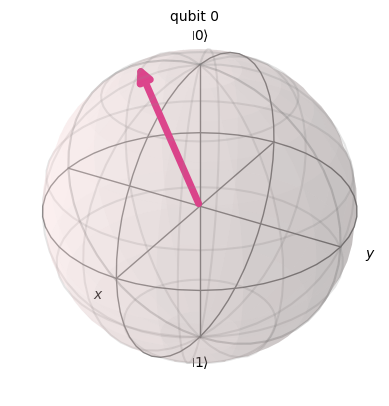

In [5]:
# ── Initialise qubit with real α and β ────────────────────────────────────────
qc_init = QuantumCircuit(1)

alpha = np.random.rand()            # Real amplitude α ∈ [0, 1)
beta  = np.sqrt(1 - alpha**2)       # Real amplitude β = sqrt(1 - α²)

print(f"Initial amplitudes:  α = {alpha:.4f},  β = {beta:.4f}")
print(f"Normalization check: |α|² + |β|² = {alpha**2 + beta**2:.6f}")

# Initialise qubit: |ψ₀⟩ = α|0⟩ + β|1⟩
psi_init = Statevector([alpha, beta])
qc_init.initialize(psi_init, 0)

# ── Random rotation angles ────────────────────────────────────────────────────
theta_x = np.random.uniform(0, 2*np.pi)   # Rₓ angle
theta_y = np.random.uniform(0, 2*np.pi)   # Rᵧ angle
theta_z = np.random.uniform(0, 2*np.pi)   # R_z angle

print(f"\nRotation angles:")
print(f"  Rₓ: {theta_x:.4f} rad  ({np.degrees(theta_x):.1f}°)")
print(f"  Rᵧ: {theta_y:.4f} rad  ({np.degrees(theta_y):.1f}°)")
print(f"  R_z: {theta_z:.4f} rad  ({np.degrees(theta_z):.1f}°)")

# ── Apply rotations ───────────────────────────────────────────────────────────
qc_init.rx(theta_x, 0)
qc_init.ry(theta_y, 0)
qc_init.rz(theta_z, 0)

# ── Final statevector ─────────────────────────────────────────────────────────
final_state = Statevector.from_instruction(qc_init)
a, b = final_state.data

print(f"\nFinal statevector:")
print(f"  α = {a:.4f}")
print(f"  β = {b:.4f}")
print(f"  |α|² = {abs(a)**2:.6f},  |β|² = {abs(b)**2:.6f}")
print(f"  Normalization: {abs(a)**2 + abs(b)**2:.6f} ✓")


# ── Bloch sphere visualisation ────────────────────────────────────────────────
print("\nBloch sphere plot:")
plot_bloch_multivector(final_state)

## 3. Approach 2: Hadamard + R_z Circuit

### Theory
A simpler circuit using just two gates:

1. **Hadamard gate (H):** Transforms |0⟩ to equal superposition (equatorial plane, θ = π/2):
$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$

2. **R_z(φ) gate:** Rotates around Z-axis, setting the azimuthal angle φ:
$$R_z(\varphi)|\psi\rangle = e^{-i\varphi Z/2}|\psi\rangle$$

### Key Constraint
Because H always maps |0⟩ to the equatorial plane (θ = π/2), and R_z only changes φ without moving off the equatorial plane:
- **This approach is restricted to the equatorial plane** — θ = π/2 always
- Measurement probabilities are always |α|² = |β|² = 0.5
- Useful for creating equal-probability superpositions with a controlled phase

After H gate: state is on the equatorial plane (θ = π/2)
Rz angle:  φ = 1.1274 rad  (64.6°)

Final statevector:
  α = 0.5977-0.3778j
  β = 0.5977+0.3778j
  |α|² = 0.500000,  |β|² = 0.500000
  Normalization: 1.000000 ✓

Bloch sphere plot:


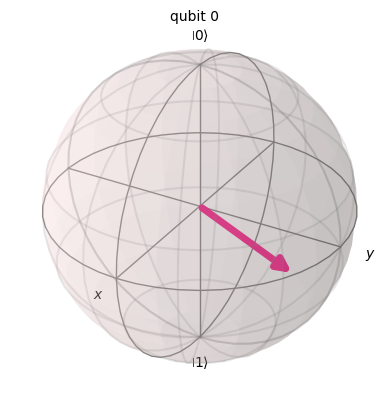

In [4]:
# ── Quantum circuit: |0⟩ → H → Rz(φ) ──────────────────────────────────────────
qc = QuantumCircuit(1)

# Step 1: Hadamard gate — creates equal superposition
# H|0⟩ = (|0⟩ + |1⟩)/√2   →   θ = π/2 on Bloch sphere
qc.h(0)
print("After H gate: state is on the equatorial plane (θ = π/2)")

# Step 2: Random phase rotation Rz(φ) — sets azimuthal angle
phi = np.random.uniform(0, 2*np.pi)
qc.rz(phi, 0)
print(f"Rz angle:  φ = {phi:.4f} rad  ({np.degrees(phi):.1f}°)")

# ── Final statevector ─────────────────────────────────────────────────────────
final_state2 = Statevector.from_instruction(qc)
a2, b2 = final_state2.data

print(f"\nFinal statevector:")
print(f"  α = {a2:.4f}")
print(f"  β = {b2:.4f}")
print(f"  |α|² = {abs(a2)**2:.6f},  |β|² = {abs(b2)**2:.6f}")
print(f"  Normalization: {abs(a2)**2 + abs(b2)**2:.6f} ✓")


# ── Bloch sphere visualisation ────────────────────────────────────────────────
print("\nBloch sphere plot:")
plot_bloch_multivector(final_state2)

## 4. Comparison: Approach 1 vs Approach 2

| Feature | Approach 1: α/β + Rotations | Approach 2: H + Rz |
|---------|-----------------------------|--------------------|
| Initial state | Real α, β amplitudes | \|0⟩ |
| Gates | initialize + Rₓ + Rᵧ + R_z | H then R_z(φ) |
| Reachable states | Any point on Bloch sphere | Equatorial plane only (θ=π/2) |
| Measurement probs | Variable \|α\|² and \|β\|² | \|α\|² = \|β\|² = 0.5 always |
| Circuit depth | 4 gates | 2 gates |
| Use case | Arbitrary state preparation | Equal superposition + phase |

## 6. Results Summary

| Experiment | Key Result |
|------------|------------|
| Bloch sphere — Approach 1 | Rₓ/Rᵧ/R_z rotations produce arbitrary state; Bloch vector (x,y,z) computed |
| Bloch sphere — Approach 2 | H + R_z circuit; state constrained to equatorial plane (θ=π/2) |

## Conclusions

1. **Bloch sphere** provides a complete geometric picture of single-qubit states.
2. **Approach 1** (direct α/β + rotations) reaches any Bloch sphere point; **Approach 2** (H+Rz) is restricted to the equatorial plane.